In [1]:
from pathlib import Path
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
DATA_DIR = Path("../data/split")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Train ada :", TRAIN_DIR.exists())
print("Val ada   :", VAL_DIR.exists())
print("Test ada  :", TEST_DIR.exists())

Train ada : True
Val ada   : True
Test ada  : True


**Load Dataset**

In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.


In [4]:
class_names = train_dataset.class_names

print("Nama kelas:")
for i, nama_kelas in enumerate(class_names):
    print(f"{i}: {nama_kelas}")

Nama kelas:
0: biological
1: cardboard
2: glass
3: metal
4: paper
5: plastic


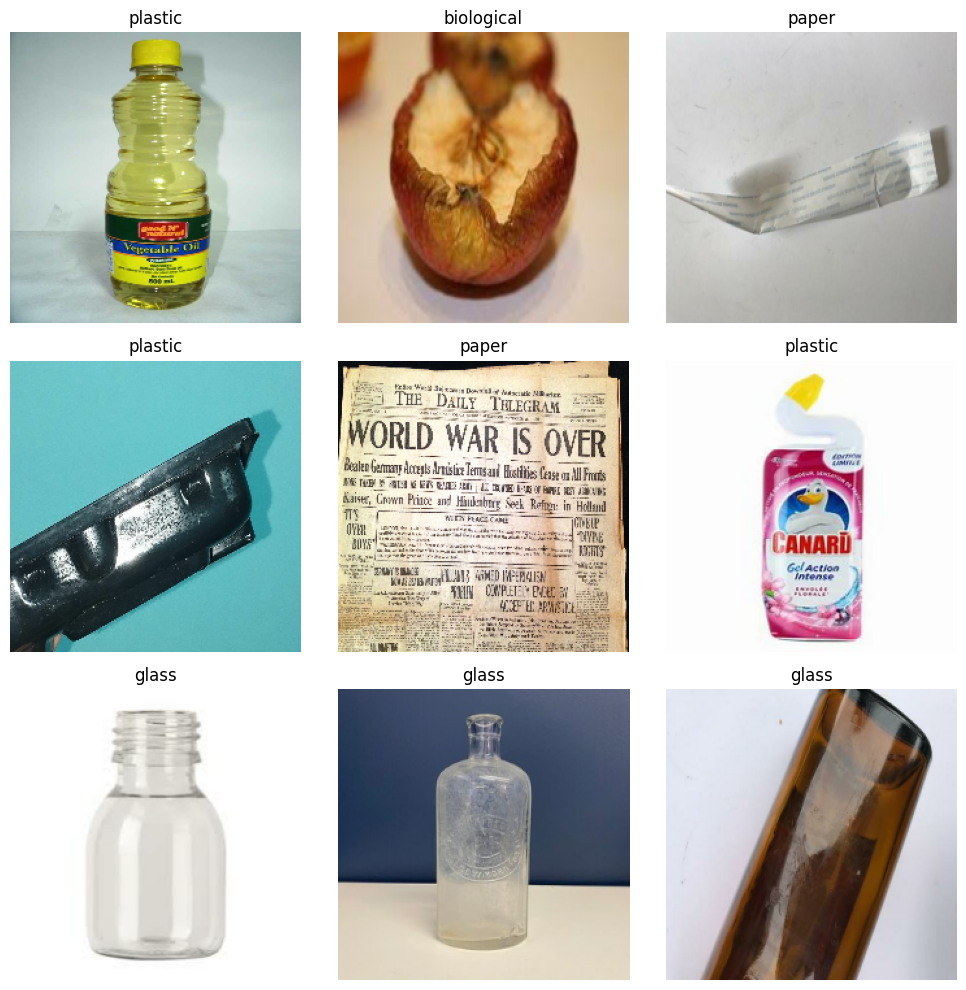

In [5]:
# preview batch dataset, untuk memastikan dataset berhasil dibaca, memastikan label benar, dan memastikan resize 224x224 berhasil
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = np.argmax(labels[i].numpy())
        plt.title(class_names[label_index])
        plt.axis("off")

plt.tight_layout()
plt.show()

**Resize Image**

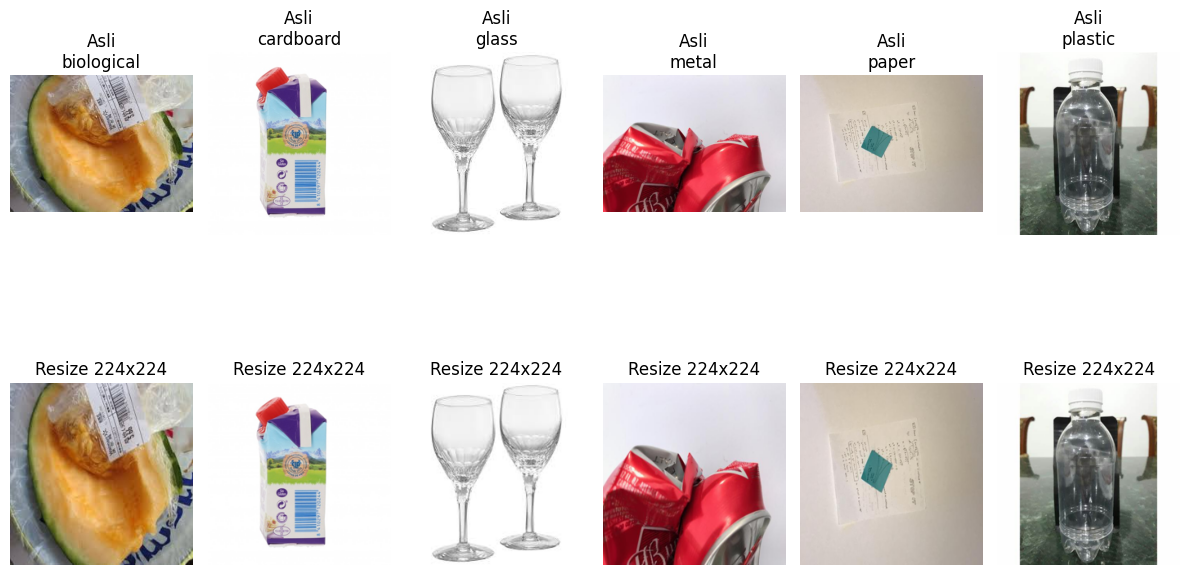

In [6]:
plt.figure(figsize=(12, 8))

for i, nama_kelas in enumerate(class_names):
    folder_kelas = TRAIN_DIR / nama_kelas
    sample_path = list(folder_kelas.glob("*"))[0]
    img_asli = Image.open(sample_path).convert("RGB")
    img_resize = img_asli.resize((224, 224))

    # gambar asli
    plt.subplot(2, 6, i + 1)
    plt.imshow(img_asli)
    plt.title(f"Asli\n{nama_kelas}")
    plt.axis("off")

    # gambar resize
    plt.subplot(2, 6, i + 7)
    plt.imshow(img_resize)
    plt.title("Resize 224x224")
    plt.axis("off")

plt.tight_layout()
plt.show()